# Code to generate the avg time comparison for the SRMC Models

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# Set the paths to the data

data_path = [r"/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/2_perf_plastic/perf_plastic_srmc_avg_time_error.csv",
             r"/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/3_plastic_dilat/plastic_dilat_srmc_avg_time_error.csv",
             r"/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/4_plastic_rate/plastic_rate_srmc_avg_time_error.csv",
             r"/mnt/data/the_deep/Geotech_Research/Master_SRMC_Comparison/Trx_Drained_Strain_Controlled/5_plastic_rate_dilat/plastic_rate_dilat_avg_time_error.csv"
             ]


# Init list of dfs to hold the data
dfs = []

for path in data_path:
    # Load the different dfs
    df = pd.read_csv(path)

    # Store the df
    dfs.append(df)

    
# Plot the data

# 



In [3]:
def plot_marker(time, error, markers, axs, color):
    for t, e, marker in zip(time, error, markers):
        # Plot the data one point at a time to get the right markers
        axs.scatter(t, e, color = color, marker = marker)

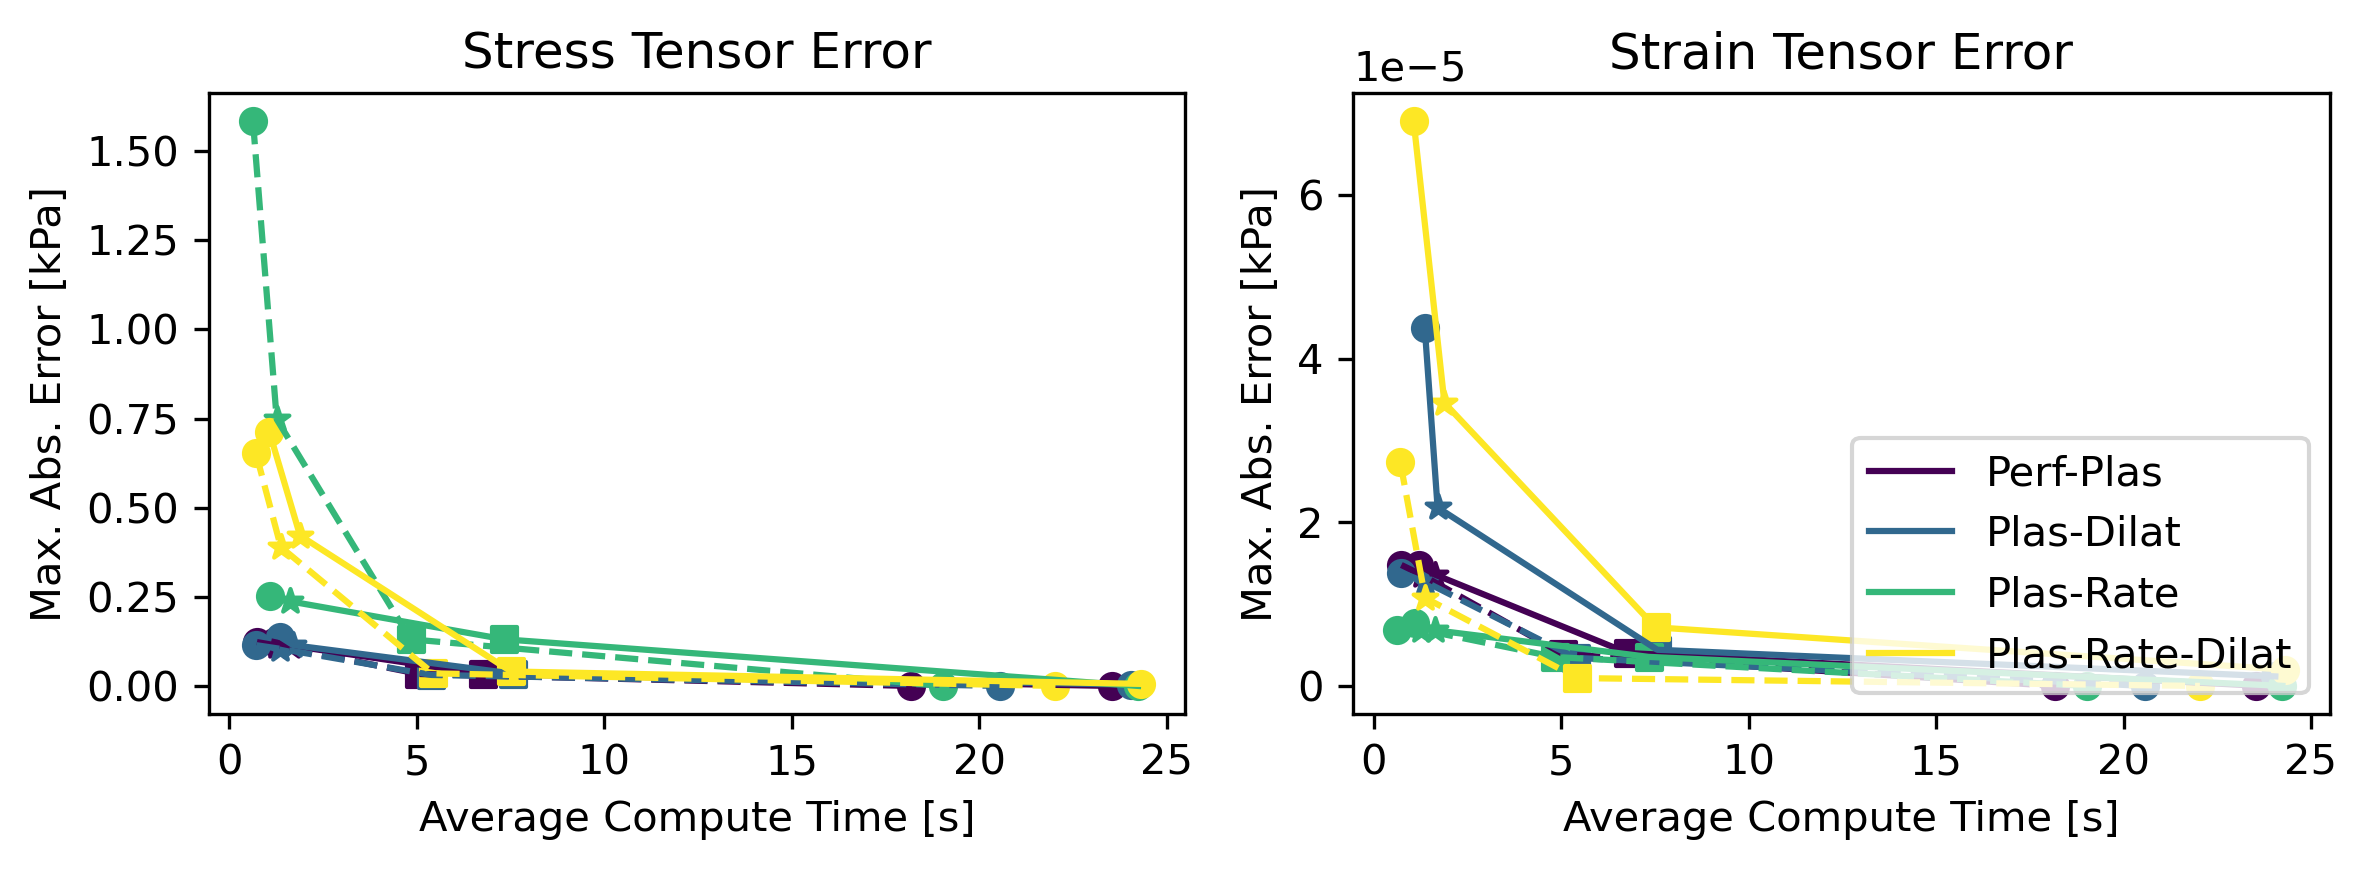

In [4]:

# Set the symbol used for the different iterations
markers = ["o", "*", "s", "o" ]

# Set the color map
colors = plt.cm.viridis(np.linspace(0, 1, len(data_path)))

# Make the OS models solid
# Make the Sub models dashed
linestyle = ["solid", "dashed"]

labels = ["Perf-Plas", "Plas-Dilat", "Plas-Rate", "Plas-Rate-Dilat"]
# Create a figure
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 3), dpi = 300)
for color, label, df in zip(colors, labels, dfs):
    # Plot the OS data
    
    # Plot the stress data
    # Plot the markers
    plot_marker(df["os_avg_time"], df["os_stress_error"], markers, axs[0], color)

    axs[0].plot(df["os_avg_time"], df["os_stress_error"], 
                color = color, linestyle = linestyle[0])

    
    # Plot the strain data
    plot_marker(df["os_avg_time"], df["os_strain_error"], markers, axs[1], color)
    axs[1].plot(df["os_avg_time"], df["os_strain_error"], 
                color = color, linestyle = linestyle[0], label = label)
    
    # Plot the sloan data
    # plot the stress data
    plot_marker(df["sloan_avg_time"], df["sloan_stress_error"], markers, axs[0], color)
    axs[0].plot(df["sloan_avg_time"], df["sloan_stress_error"], 
                color = color, linestyle = linestyle[1])

    # Plot the strain data
    plot_marker(df["sloan_avg_time"], df["sloan_strain_error"], markers, axs[1], color)
    axs[1].plot(df["sloan_avg_time"], df["sloan_strain_error"], 
                color = color, linestyle = linestyle[1])

# Set the plot information
axs[0].set_title("Stress Tensor Error")
axs[0].set_xlabel("Average Compute Time [s]")
axs[0].set_ylabel("Max. Abs. Error [kPa]")

axs[1].set_title("Strain Tensor Error")
axs[1].set_xlabel("Average Compute Time [s]")
axs[1].set_ylabel("Max. Abs. Error [kPa]")
axs[1].legend(loc = "lower right")


plt.tight_layout()

image_name = "srmc_tensor_error.pdf"
srmc_latex_folder = "/home/jmoore/Documents/Master_Thesis/chapters/Constitutive_Modelling/srmc_images"
save_fig_path = os.path.join(srmc_latex_folder, image_name)
fig.savefig(save_fig_path, format = "pdf", bbox_inches = 'tight')


Sloan Et al is dashed